# Seasonal Agriculture Performance Analysis

**Dataset:** `agriculture_dataset.csv` — 4000 farm records across Indian states  
**Columns:** Farm ID, State, District, Crop, Season, Farm Area, Rainfall, Temperature, Humidity,
Sunlight, Soil pH, Soil Moisture, NPK nutrients, Irrigation Method, Fertilizer, Pesticide,
Seed Quality, Yield, Production, Market Price, Cost, Revenue, Profit, Water Usage, Water Efficiency, Disease/Pest Risk

---
### Key Questions Answered:
1. How does yield and profit vary across seasons?
2. Which crops perform best in each season?
3. How do environmental factors correlate with outcomes?
4. How does resource usage vary by season?
5. Which states and irrigation methods are most efficient?
6. What drives profitability?

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120
SEASON_COLORS = {'Kharif': '#2ecc71', 'Rabi': '#3498db', 'Zaid': '#e67e22'}

# Running locally: place agriculture_dataset.csv in the same folder.
# Running on Google Colab: use the try/except block below to upload.
try:
    df = pd.read_csv('agriculture_dataset.csv')
except FileNotFoundError:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Data Exploration & Cleaning

In [2]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 no

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,...,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,...,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,...,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,...,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.78,6.60,6.26,21.70,98.50,46.20,86.20,...,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,...,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,...,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,...,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [3]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values! Dataset is clean.')

print('\n=== Seasons Present ===')
print(df['Season'].value_counts())

print('\n=== Crops Present ===')
print(df['Crop'].value_counts())

print('\n=== States Present ===')
print(df['State'].nunique(), 'unique states')

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print('\nData cleaning complete.')

=== Missing Values ===
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

=== Seasons Present ===
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

=== Crops Present ===
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

=== States Present ===
8 unique states

Data cleaning complete.


## 3. Seasonal Patterns & Trends
### Q1: How do yield and profit vary across seasons?

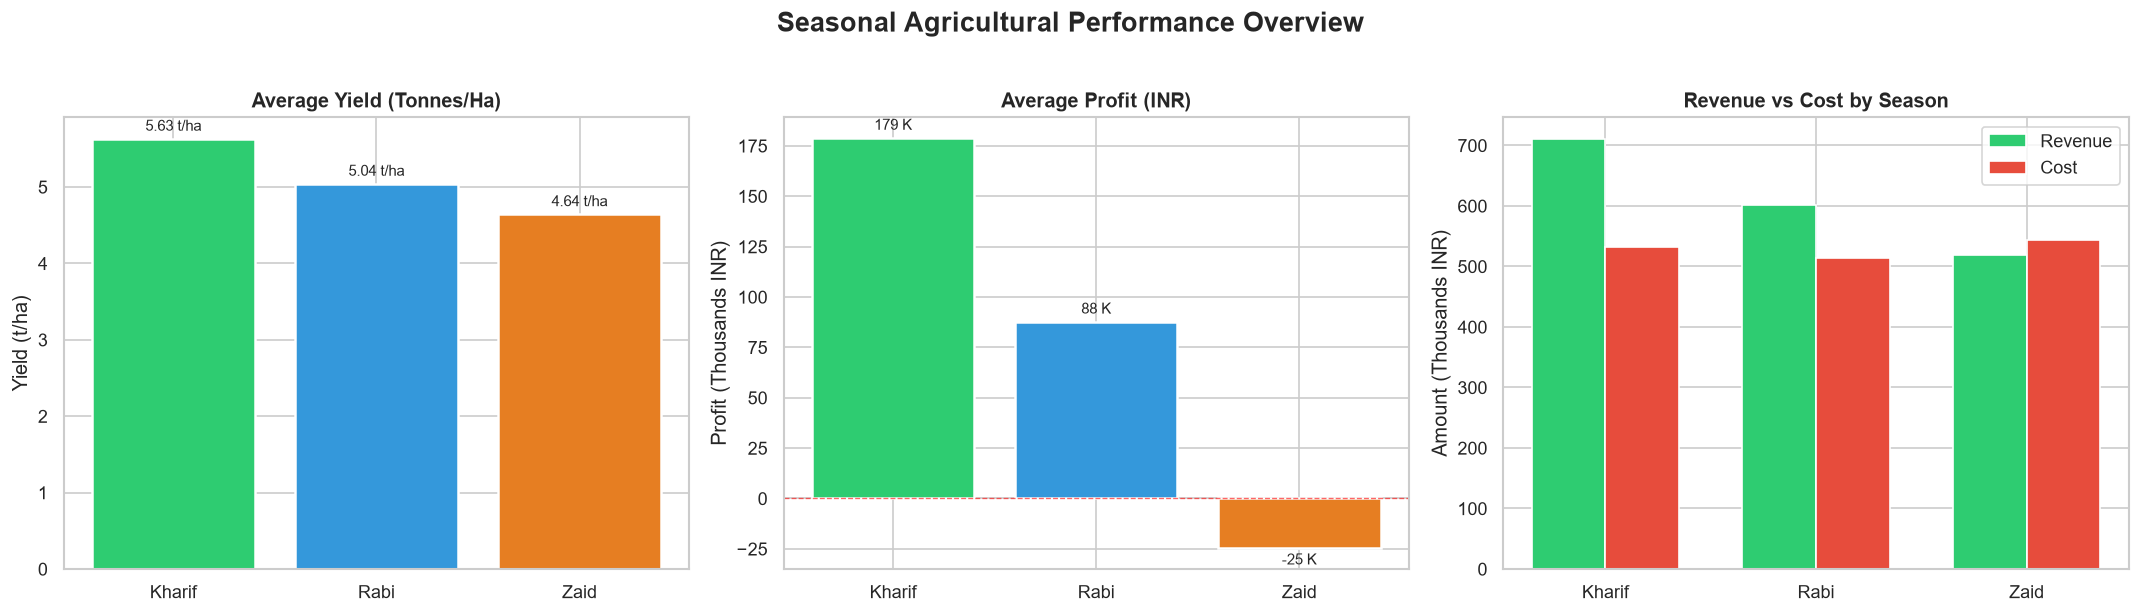

Season  Avg_Yield    Avg_Profit   Avg_Revenue      Avg_Cost  Count
Kharif   5.628612 178914.647555 710719.055649 531804.408094   1779
  Rabi   5.039435  87689.470191 601526.048556 513836.578365   1627
  Zaid   4.641313 -24804.824916 519171.904040 543976.728956    594


In [4]:
seasonal = df.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Count=('Farm_ID', 'count')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonal Agricultural Performance Overview', fontsize=16, fontweight='bold', y=1.02)

bars = axes[0].bar(seasonal['Season'], seasonal['Avg_Yield'],
                   color=[SEASON_COLORS[s] for s in seasonal['Season']], edgecolor='white', linewidth=1.5)
axes[0].bar_label(bars, fmt='%.2f t/ha', padding=3, fontsize=9)
axes[0].set_title('Average Yield (Tonnes/Ha)', fontweight='bold')
axes[0].set_ylabel('Yield (t/ha)')

bars2 = axes[1].bar(seasonal['Season'], seasonal['Avg_Profit'] / 1e3,
                    color=[SEASON_COLORS[s] for s in seasonal['Season']], edgecolor='white', linewidth=1.5)
axes[1].bar_label(bars2, fmt='%.0f K', padding=3, fontsize=9)
axes[1].set_title('Average Profit (INR)', fontweight='bold')
axes[1].set_ylabel('Profit (Thousands INR)')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

x = np.arange(len(seasonal))
w = 0.35
axes[2].bar(x - w/2, seasonal['Avg_Revenue'] / 1e3, w, label='Revenue', color='#2ecc71', edgecolor='white')
axes[2].bar(x + w/2, seasonal['Avg_Cost'] / 1e3, w, label='Cost', color='#e74c3c', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(seasonal['Season'])
axes[2].set_title('Revenue vs Cost by Season', fontweight='bold')
axes[2].set_ylabel('Amount (Thousands INR)')
axes[2].legend()

plt.tight_layout()
plt.savefig('seasonal_performance.png', bbox_inches='tight', dpi=150)
plt.show()
print(seasonal.to_string(index=False))

### Q2: Which crops perform best in each season?

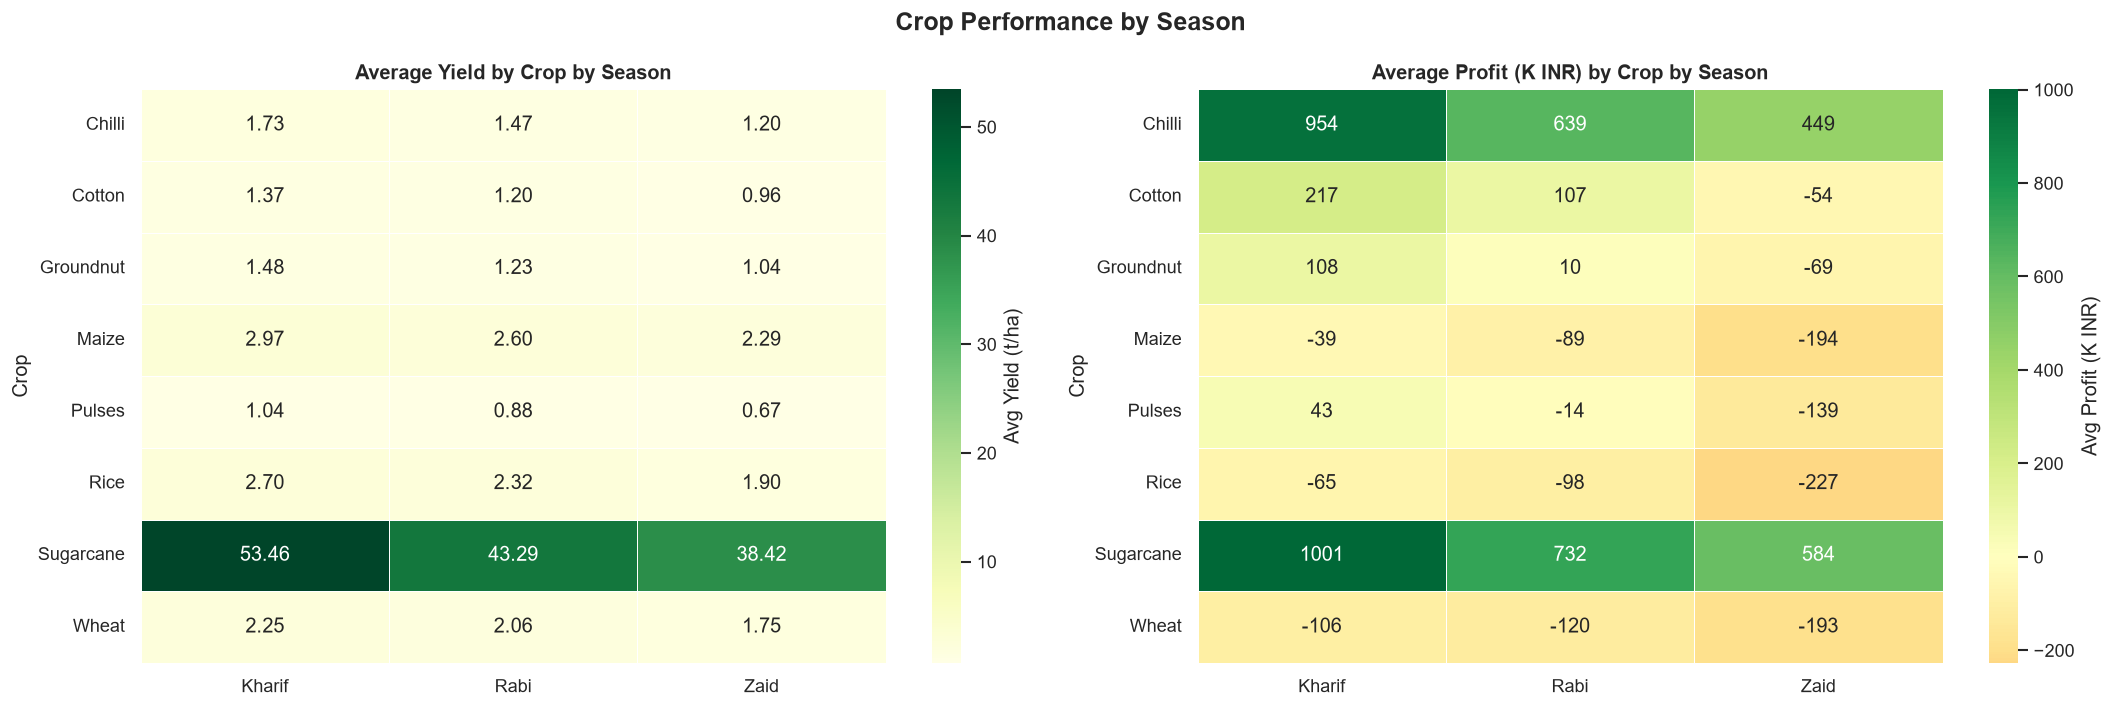

In [5]:
crop_season = df.groupby(['Season', 'Crop']).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Crop Performance by Season', fontsize=15, fontweight='bold')

pivot_yield = crop_season.pivot(index='Crop', columns='Season', values='Avg_Yield')
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGn', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Avg Yield (t/ha)'})
axes[0].set_title('Average Yield by Crop by Season', fontweight='bold')
axes[0].set_xlabel('')

pivot_profit = crop_season.pivot(index='Crop', columns='Season', values='Avg_Profit') / 1e3
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Avg Profit (K INR)'}, center=0)
axes[1].set_title('Average Profit (K INR) by Crop by Season', fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('crop_season_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

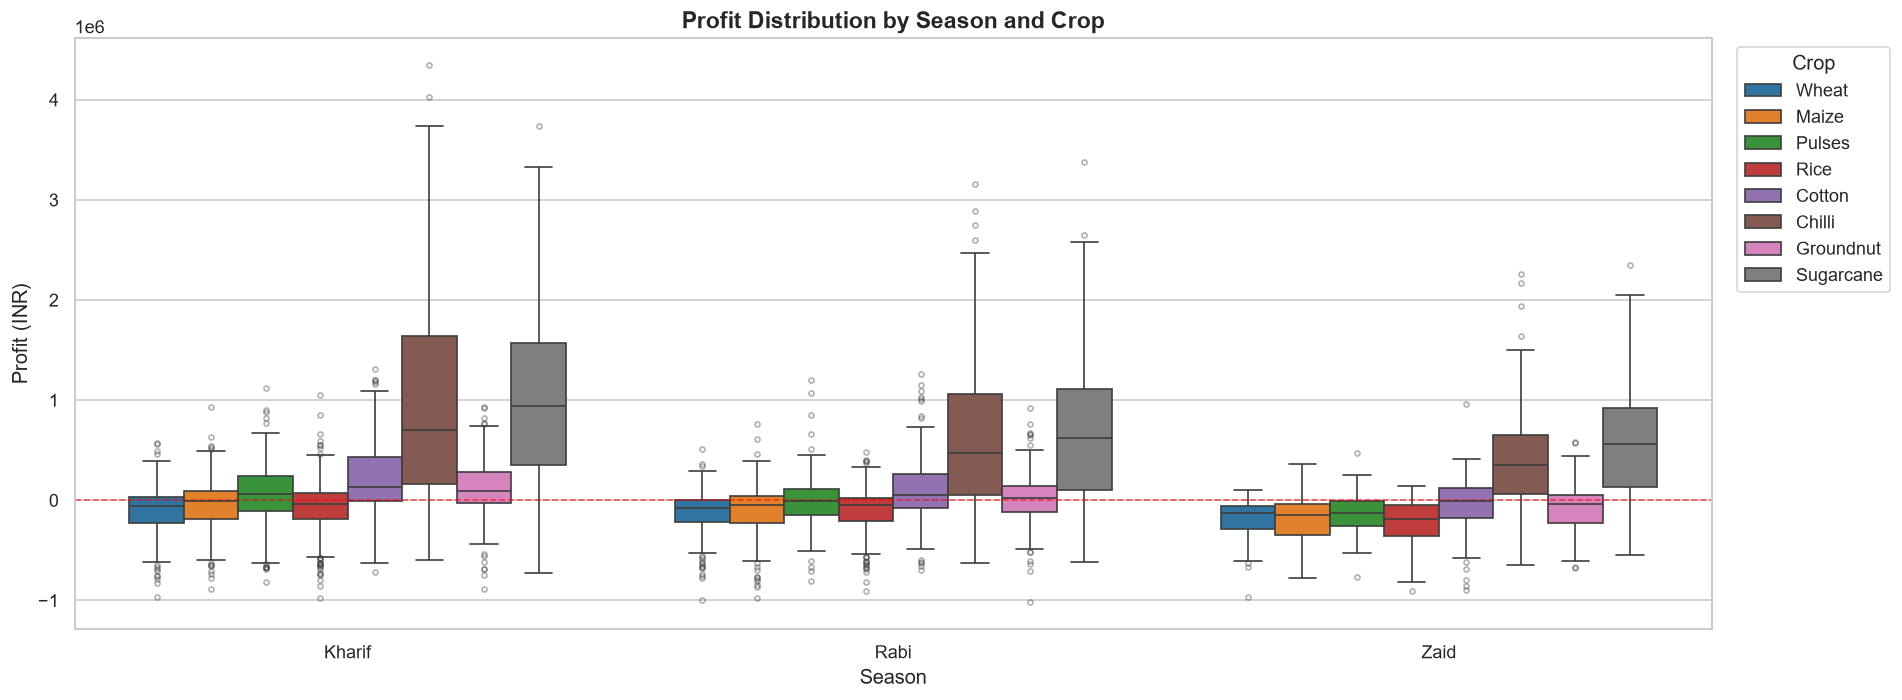

In [6]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Crop',
            palette='tab10', flierprops=dict(marker='o', markersize=3, alpha=0.4))
plt.title('Profit Distribution by Season and Crop', fontsize=14, fontweight='bold')
plt.ylabel('Profit (INR)')
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Crop')
plt.tight_layout()
plt.savefig('profit_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Environmental Conditions & Agricultural Outcomes
### Q3: How do environmental factors correlate with yield and profit?

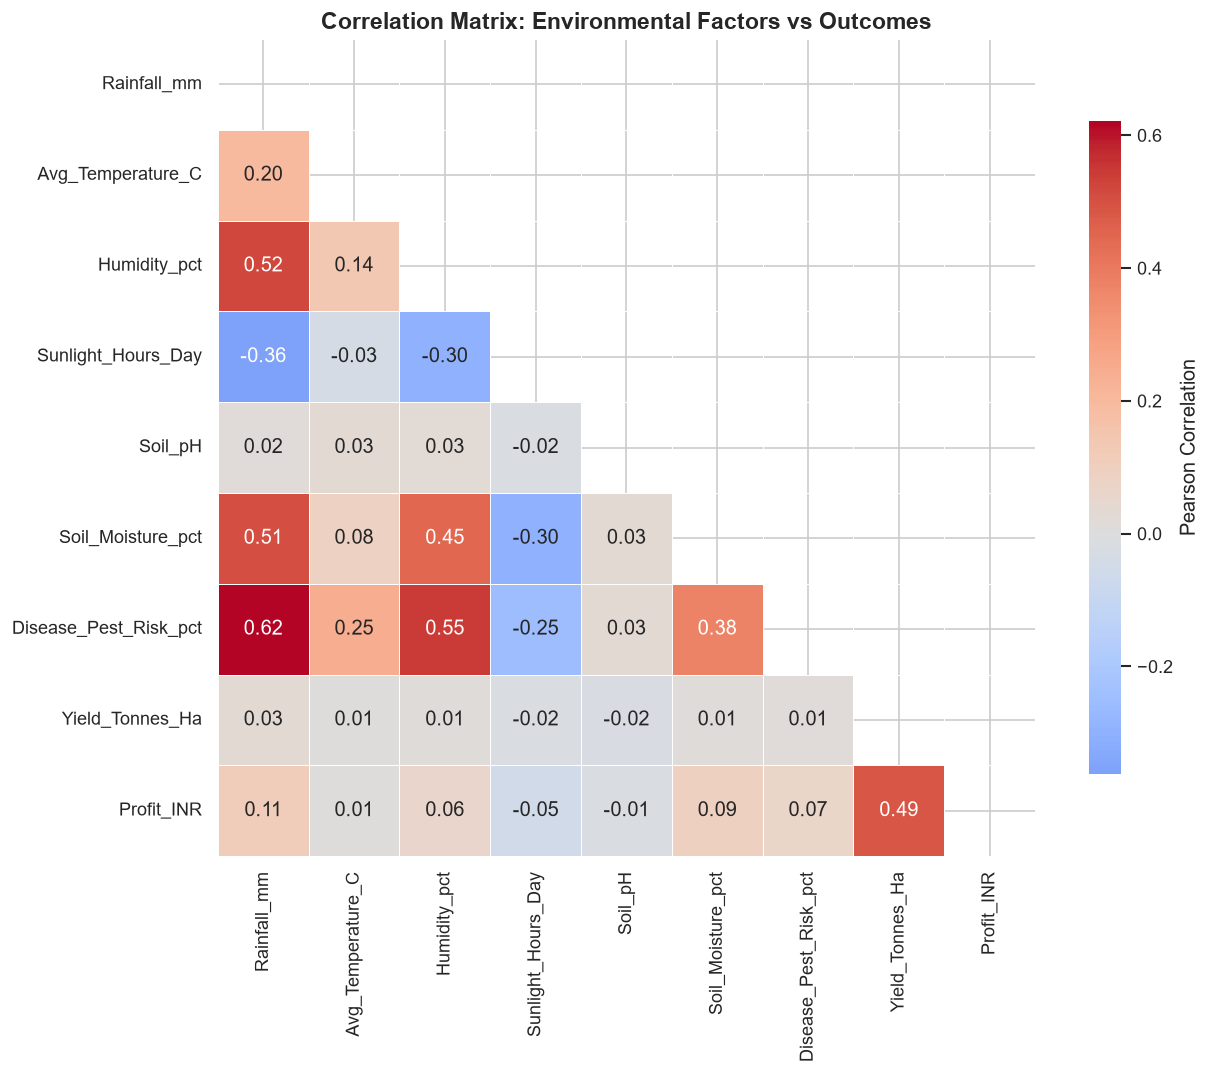

In [7]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
            'Soil_pH', 'Soil_Moisture_pct', 'Disease_Pest_Risk_pct',
            'Yield_Tonnes_Ha', 'Profit_INR']

corr = df[env_cols].corr()
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
plt.title('Correlation Matrix: Environmental Factors vs Outcomes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

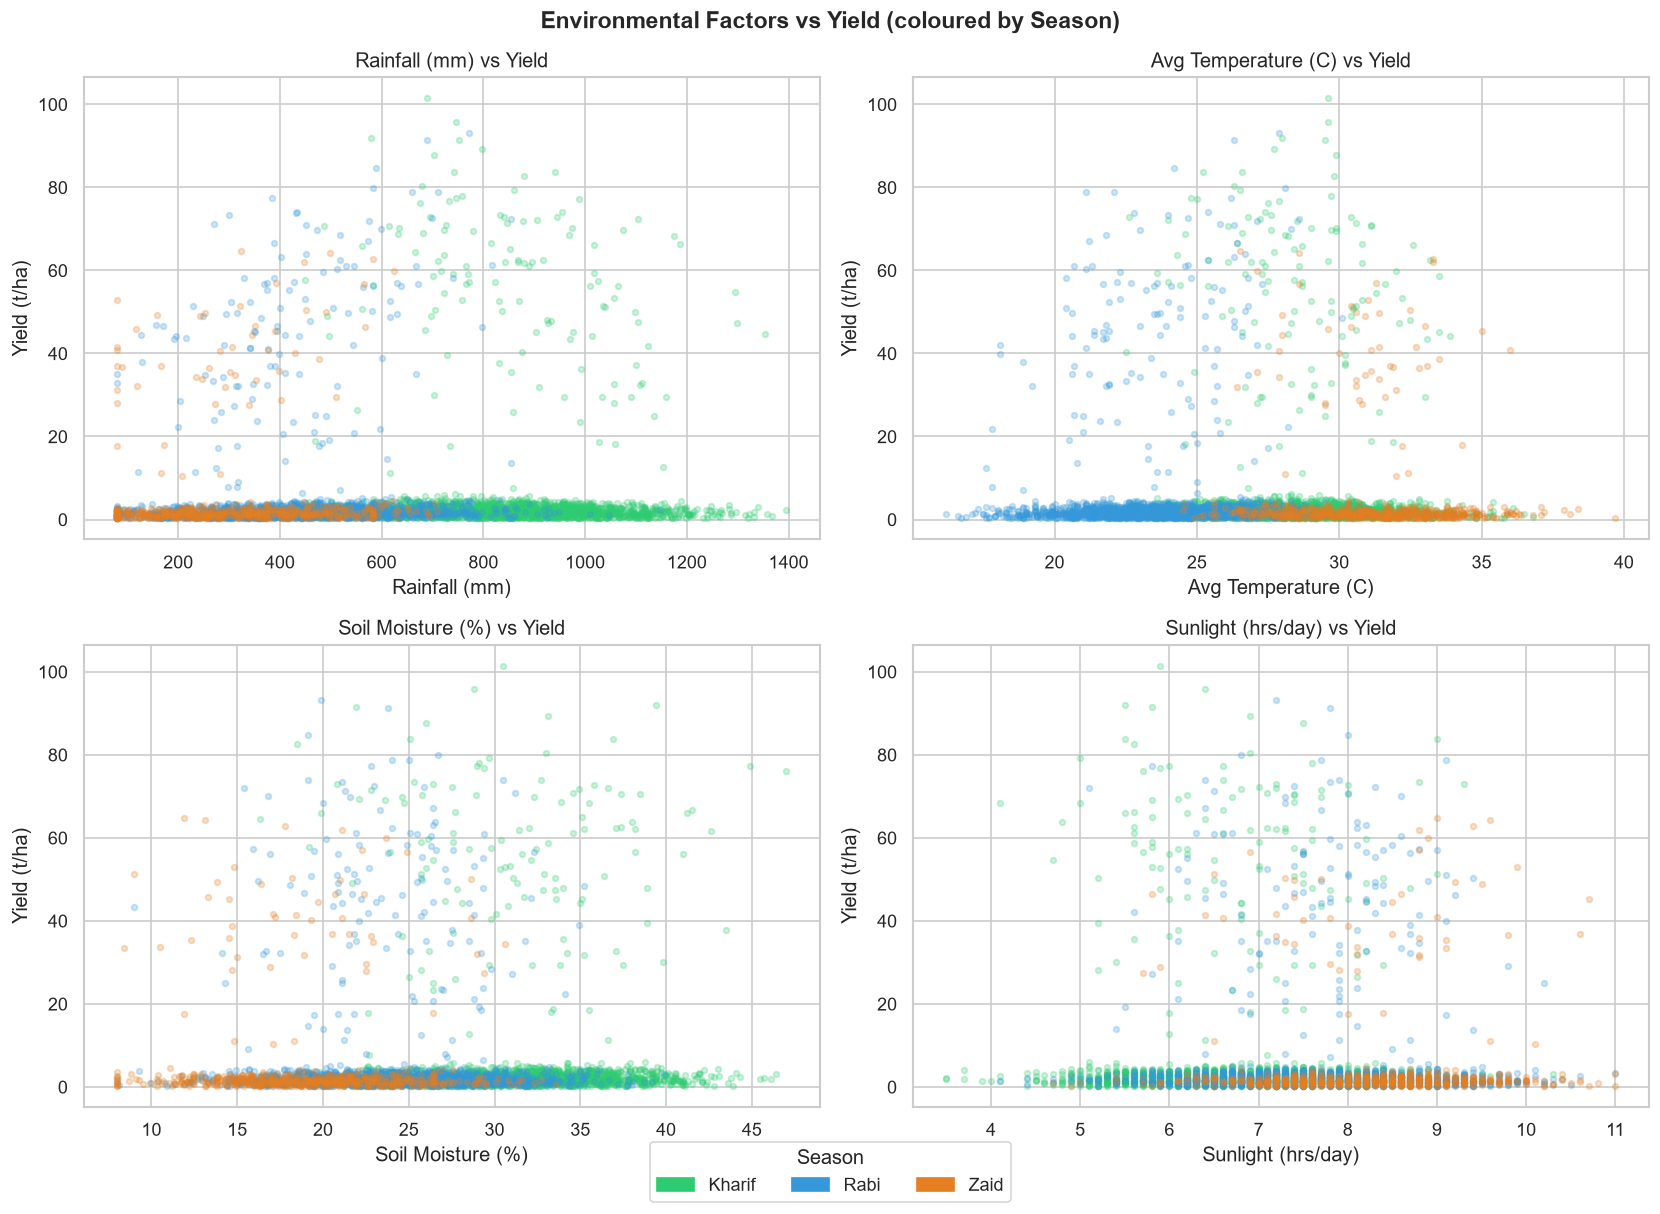

In [8]:
factors = ['Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Sunlight_Hours_Day']
labels  = ['Rainfall (mm)', 'Avg Temperature (C)', 'Soil Moisture (%)', 'Sunlight (hrs/day)']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Environmental Factors vs Yield (coloured by Season)', fontsize=14, fontweight='bold')

for ax, factor, lbl in zip(axes.flatten(), factors, labels):
    for season, color in SEASON_COLORS.items():
        subset = df[df['Season'] == season]
        ax.scatter(subset[factor], subset['Yield_Tonnes_Ha'],
                   alpha=0.25, s=12, color=color, label=season)
    ax.set_xlabel(lbl)
    ax.set_ylabel('Yield (t/ha)')
    ax.set_title(f'{lbl} vs Yield')

handles = [mpatches.Patch(color=c, label=s) for s, c in SEASON_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), title='Season')
plt.tight_layout()
plt.savefig('env_vs_yield.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Resource Usage Variations Across Seasons
### Q4: How does resource usage (water, fertilizer, pesticide) change by season?

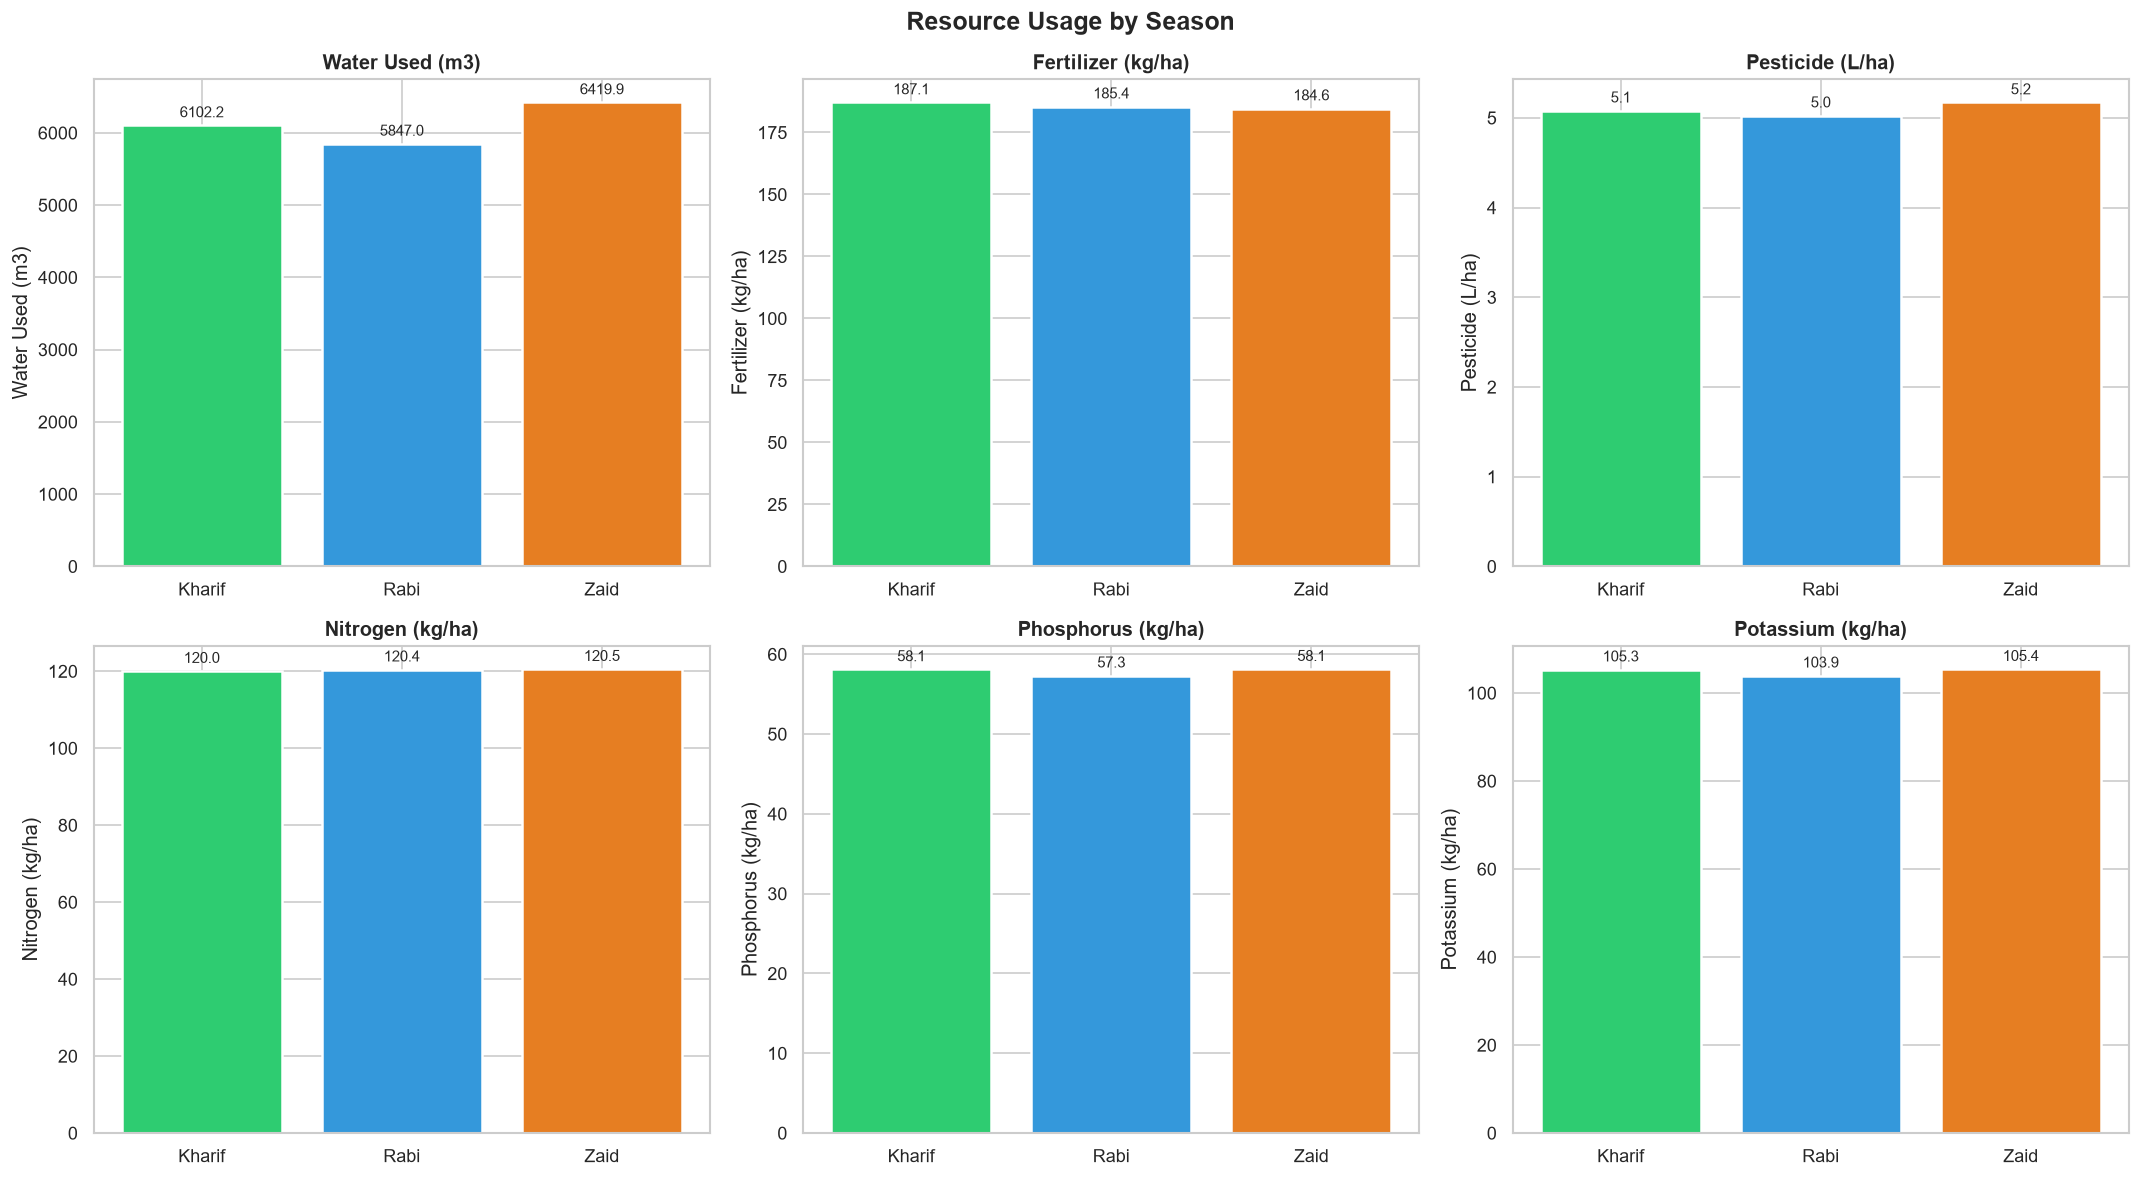

Season  Water_Used_m3  Fertilizer_kg_ha  Pesticide_Litre_ha  Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha
Kharif        6102.20            187.08                5.08          120.02             58.10           105.30
  Rabi        5846.99            185.41                5.02          120.40             57.31           103.93
  Zaid        6419.89            184.64                5.17          120.53             58.13           105.42


In [9]:
resource_cols = ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
                 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']
resource = df.groupby('Season')[resource_cols].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Resource Usage by Season', fontsize=15, fontweight='bold')

titles = ['Water Used (m3)', 'Fertilizer (kg/ha)', 'Pesticide (L/ha)',
          'Nitrogen (kg/ha)', 'Phosphorus (kg/ha)', 'Potassium (kg/ha)']

for ax, col, title in zip(axes.flatten(), resource_cols, titles):
    colors = [SEASON_COLORS[s] for s in resource['Season']]
    bars = ax.bar(resource['Season'], resource[col], color=colors, edgecolor='white', linewidth=1.5)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig('resource_usage.png', bbox_inches='tight', dpi=150)
plt.show()
print(resource.round(2).to_string(index=False))

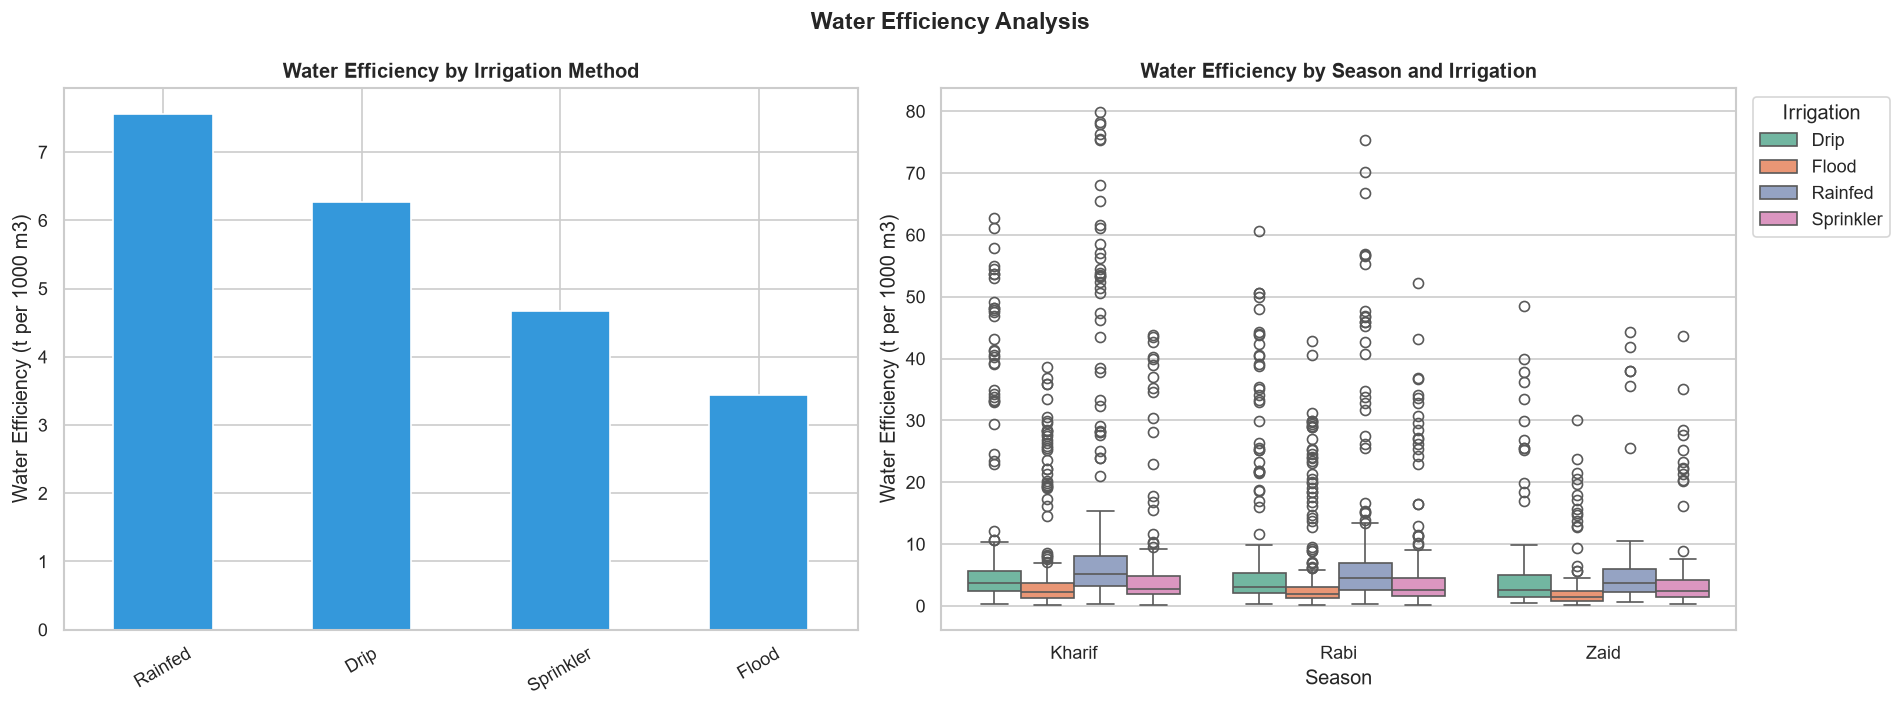

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Water Efficiency Analysis', fontsize=14, fontweight='bold')

irr_eff = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)
irr_eff.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Water Efficiency by Irrigation Method', fontweight='bold')
axes[0].set_ylabel('Water Efficiency (t per 1000 m3)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3',
            hue='Irrigation_Method', ax=axes[1], palette='Set2')
axes[1].set_title('Water Efficiency by Season and Irrigation', fontweight='bold')
axes[1].set_ylabel('Water Efficiency (t per 1000 m3)')
axes[1].legend(title='Irrigation', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('water_efficiency.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. State-wise & Regional Analysis
### Q5: Which states perform best in terms of yield and profitability?

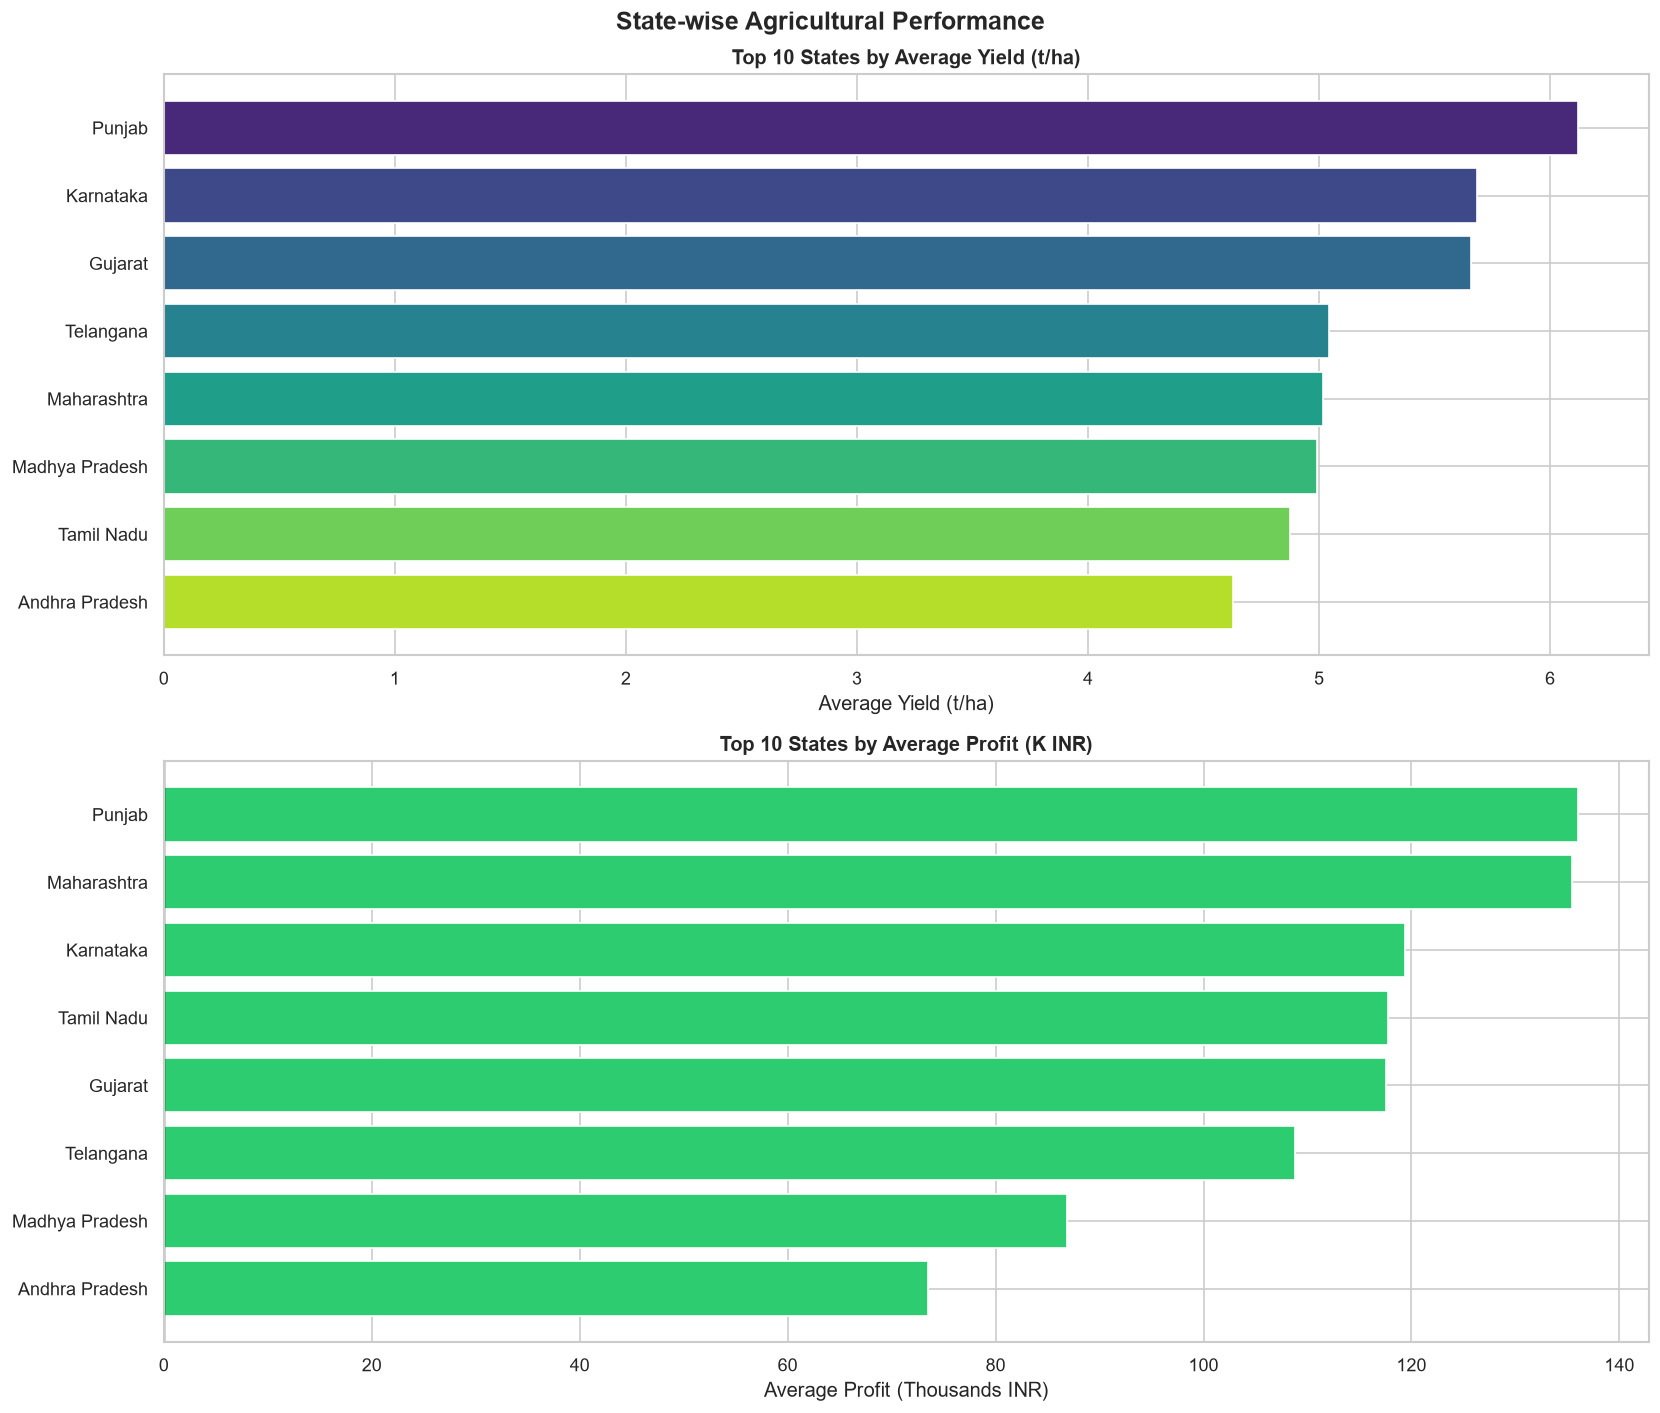

In [11]:
state_perf = df.groupby('State').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Total_Production=('Production_Tonnes', 'sum'),
    Farm_Count=('Farm_ID', 'count')
).reset_index().sort_values('Avg_Yield', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('State-wise Agricultural Performance', fontsize=15, fontweight='bold')

top_yield = state_perf.head(10)
axes[0].barh(top_yield['State'], top_yield['Avg_Yield'],
             color=sns.color_palette('viridis', len(top_yield)))
axes[0].set_title('Top 10 States by Average Yield (t/ha)', fontweight='bold')
axes[0].set_xlabel('Average Yield (t/ha)')
axes[0].invert_yaxis()

state_profit = state_perf.sort_values('Avg_Profit', ascending=False).head(10)
colors = ['#2ecc71' if p >= 0 else '#e74c3c' for p in state_profit['Avg_Profit']]
axes[1].barh(state_profit['State'], state_profit['Avg_Profit'] / 1e3, color=colors)
axes[1].set_title('Top 10 States by Average Profit (K INR)', fontweight='bold')
axes[1].set_xlabel('Average Profit (Thousands INR)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('state_performance.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Profitability Drivers & NPK Analysis
### Q6: What drives profitability? Soil nutrients vs yield.

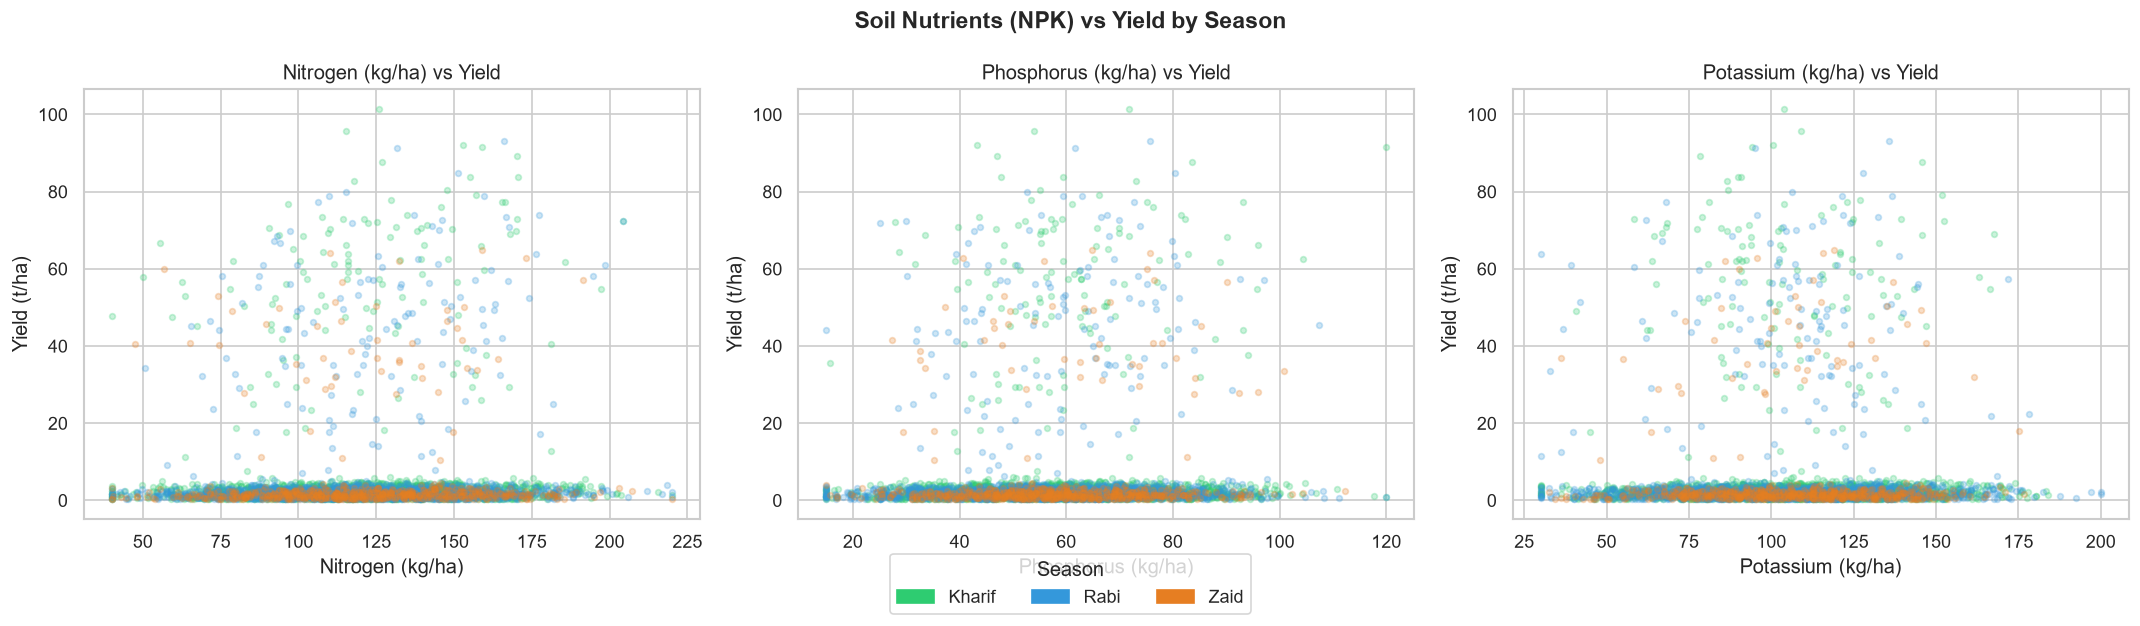

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Soil Nutrients (NPK) vs Yield by Season', fontsize=14, fontweight='bold')

for ax, nutrient, label in zip(axes,
    ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha'],
    ['Nitrogen (kg/ha)', 'Phosphorus (kg/ha)', 'Potassium (kg/ha)']):
    for season, color in SEASON_COLORS.items():
        subset = df[df['Season'] == season]
        ax.scatter(subset[nutrient], subset['Yield_Tonnes_Ha'],
                   alpha=0.25, s=12, color=color, label=season)
    ax.set_xlabel(label)
    ax.set_ylabel('Yield (t/ha)')
    ax.set_title(f'{label} vs Yield')

handles = [mpatches.Patch(color=c, label=s) for s, c in SEASON_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04), title='Season')
plt.tight_layout()
plt.savefig('npk_yield.png', bbox_inches='tight', dpi=150)
plt.show()

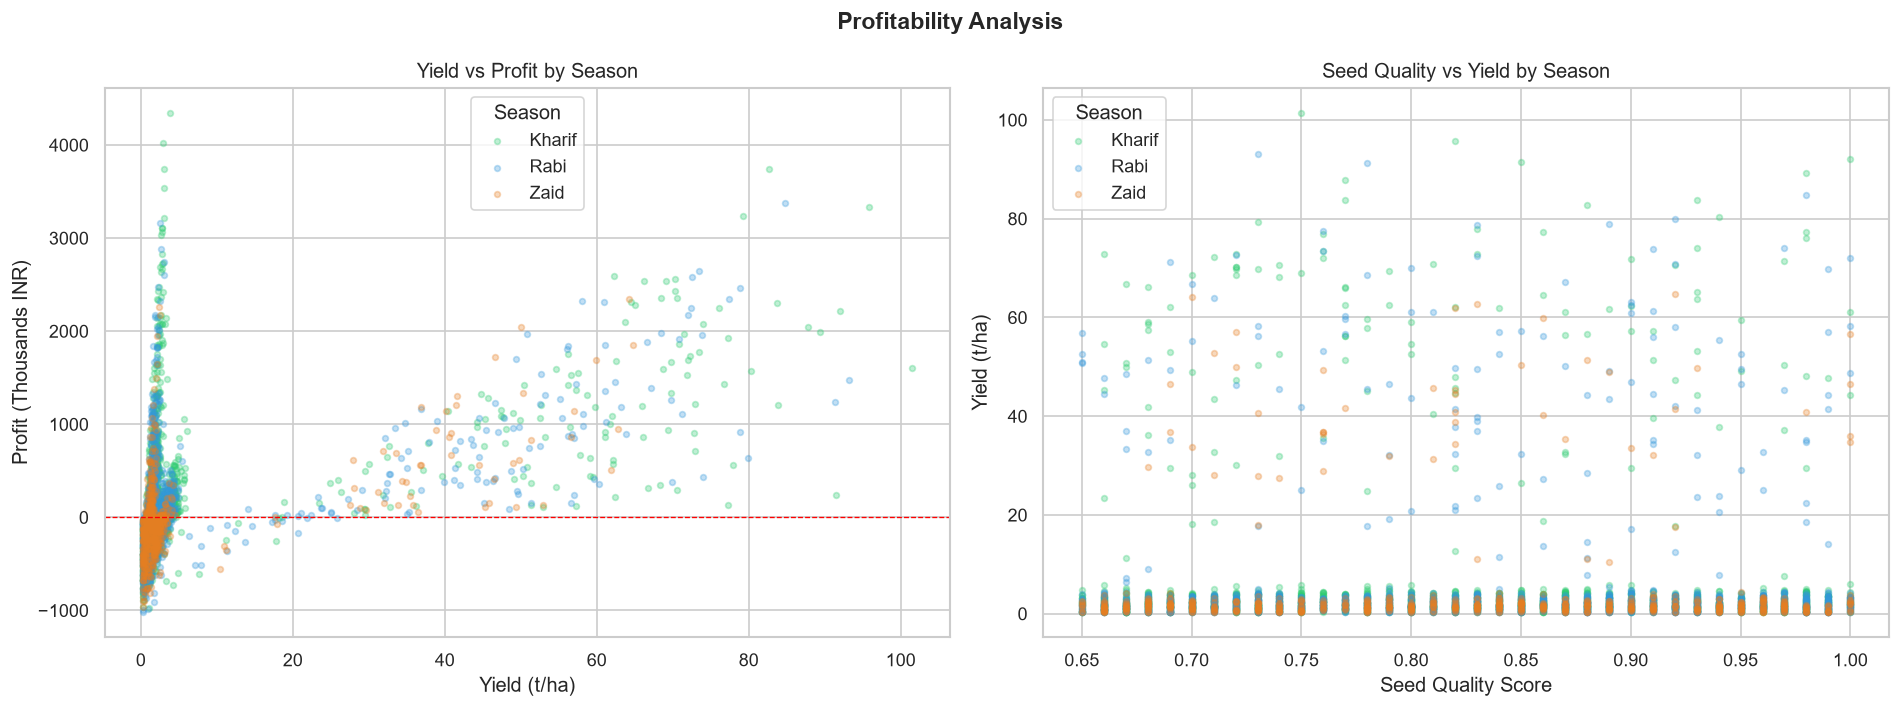

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Profitability Analysis', fontsize=14, fontweight='bold')

for season, color in SEASON_COLORS.items():
    subset = df[df['Season'] == season]
    axes[0].scatter(subset['Yield_Tonnes_Ha'], subset['Profit_INR'] / 1e3,
                    alpha=0.3, s=12, color=color, label=season)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Yield (t/ha)')
axes[0].set_ylabel('Profit (Thousands INR)')
axes[0].set_title('Yield vs Profit by Season')
axes[0].legend(title='Season')

for season, color in SEASON_COLORS.items():
    subset = df[df['Season'] == season]
    axes[1].scatter(subset['Seed_Quality_Score'], subset['Yield_Tonnes_Ha'],
                    alpha=0.3, s=12, color=color, label=season)
axes[1].set_xlabel('Seed Quality Score')
axes[1].set_ylabel('Yield (t/ha)')
axes[1].set_title('Seed Quality vs Yield by Season')
axes[1].legend(title='Season')

plt.tight_layout()
plt.savefig('profitability.png', bbox_inches='tight', dpi=150)
plt.show()

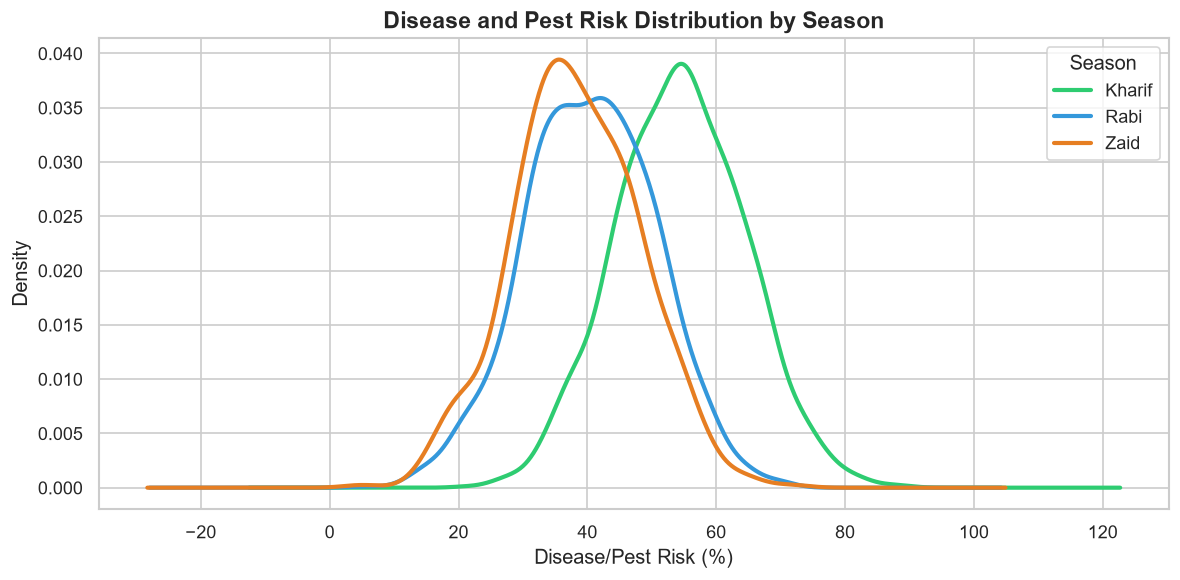

In [14]:
plt.figure(figsize=(10, 5))
for season, color in SEASON_COLORS.items():
    subset = df[df['Season'] == season]['Disease_Pest_Risk_pct']
    subset.plot(kind='kde', label=season, color=color, linewidth=2.5)
plt.title('Disease and Pest Risk Distribution by Season', fontsize=14, fontweight='bold')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Density')
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('disease_risk.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Summary Dashboard

In [15]:
print('=== Best Crop by Yield per Season ===')
print(df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean()
       .reset_index().sort_values(['Season', 'Yield_Tonnes_Ha'], ascending=[True, False])
       .groupby('Season').first().reset_index()[['Season', 'Crop', 'Yield_Tonnes_Ha']].to_string(index=False))

print('\n=== Best Crop by Profit per Season ===')
print(df.groupby(['Season', 'Crop'])['Profit_INR'].mean()
       .reset_index().sort_values(['Season', 'Profit_INR'], ascending=[True, False])
       .groupby('Season').first().reset_index()[['Season', 'Crop', 'Profit_INR']].to_string(index=False))

print('\n=== Best Irrigation Method (Water Efficiency) ===')
print(df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean()
       .sort_values(ascending=False).reset_index().to_string(index=False))

print('\n=== Profitability Rate by Season ===')
for s in df['Season'].unique():
    sub = df[df['Season'] == s]
    profitable_pct = (sub['Profit_INR'] > 0).mean() * 100
    print(f'  {s}: {profitable_pct:.1f}% farms profitable')

=== Best Crop by Yield per Season ===
Season      Crop  Yield_Tonnes_Ha
Kharif Sugarcane        53.459120
  Rabi Sugarcane        43.286124
  Zaid Sugarcane        38.423922

=== Best Crop by Profit per Season ===
Season      Crop   Profit_INR
Kharif Sugarcane 1.000791e+06
  Rabi Sugarcane 7.316129e+05
  Zaid Sugarcane 5.836358e+05

=== Best Irrigation Method (Water Efficiency) ===
Irrigation_Method  Water_Efficiency_t_per_1000m3
          Rainfed                       7.563784
             Drip                       6.267129
        Sprinkler                       4.669805
            Flood                       3.438853

=== Profitability Rate by Season ===
  Kharif: 57.8% farms profitable
  Rabi: 48.9% farms profitable
  Zaid: 35.5% farms profitable


## 9. Conclusions & Recommendations

### Key Findings:
| Area | Finding |
|---|---|
| **Seasonal Yield** | Yield varies meaningfully across Kharif, Rabi, and Zaid seasons |
| **Seasonal Profit** | Some seasons consistently generate higher profit margins |
| **Top Crops** | Different crops are best-suited to each season — aligning crop choice to season is critical |
| **Environmental Factors** | Rainfall, temperature, and soil moisture show notable correlation with yield |
| **Resource Usage** | Water and fertilizer demand differs by season, offering optimization opportunities |
| **Irrigation** | Drip/Sprinkler irrigation shows better water efficiency than flood irrigation |
| **Disease Risk** | Disease and pest risk varies by season — preventive action should be season-aware |
| **Seed Quality** | Higher seed quality scores tend to correlate with better yield outcomes |

### Recommendations:
1. **Season-crop alignment**: Prioritize crops that historically perform best in each season.
2. **Water management**: Switch to drip/sprinkler irrigation, especially in Zaid (summer) season.
3. **Fertilizer optimization**: Tailor NPK application based on soil tests per season.
4. **Disease management**: Implement preventive pest control in high-risk seasons.
5. **Seed investment**: Investing in higher-quality seeds improves returns across all seasons.